![BasQ banner](logo_challenge.png)

# <b>Quantum Neural Network (QNN) Regressor </b>
**Authors:** Benjamin Tirado and Unai Aseguinolaza  
**Institution:** Basque Quantum (BasQ)  

<a id="goal"></a>
<div class="alert alert-block alert-success">
    
<b>Goal of this notebook: </b> Build and train a very small QNN using a **single qubit**. We will use it as a simple regressor that learns a one-dimensional nonlinear function from noisy data.

# <b>Table of Contents</b>

* [Background](#background)
* [Pre-requisites](#prereq)
* [Dataset Creation & Preprocessing](#dataprepro) 
* [Parametric Circuit: The Quantum Neuron](#param)
* [Quantum Neural Network and Observable definition](#qnn)
* [Training with Regularization](#train)
* [Results and Evaluation](#res)
* [Moving forward](#move)
* [Useful resources](#use)

## <b>Background </b> <a id="background"></a>

A **Quantum Neural Network (QNN)** is a machine learning model that uses a parameterized quantum circuit as part of its algorithm. Similar to a classical neural network, a QNN contains trainable parameters that are optimized to reduce a loss function. However, instead of applying layers of classical operations, a QNN applies quantum gates to qubits and extracts information through measurements.

QNNs are useful because they allow us to explore how quantum circuits can be used for learning tasks such as classification, regression, and function approximation. In particular, parameterized quantum circuits can represent complex transformations in Hilbert space, which may provide expressive models using relatively few qubits and parameters. While practical quantum advantage is still an active research question, QNNs are a valuable tool for understanding the intersection of quantum computing and machine learning.

# <b>Pre-requisites </b> <a id="prereq"></a>
For starters, make sure that you have installed the Qiskit SDK and its supporting modules: `qiskit_aer`(for noiseless simulations) and `qiskit_ibm_runtime` (for real-hardware experiments), as well as the visualization package `qiskit[visualization]`. Additionally, we will use `qiskit_machine_learning` for the quantum components of the neural network, `qiskit_algorithms` for the optimizer and `sklearn` for data preprocessing and splitting.

In [ ]:
# %pip install qiskit qiskit_aer qiskit_ibm_runtime qiskit[visualization] qiskit_machine_learning qiskit_algorithms sklearn

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.algorithms import NeuralNetworkRegressor
from qiskit_algorithms.optimizers import L_BFGS_B
from qiskit.quantum_info import SparsePauliOp
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# <b>Dataset Creation & Preprocessing </b> <a id="dataprepro"></a>
We generate a noisy quadratic dataset: 

$$
y = 1 - x^2 + \epsilon
$$

where $x$ is the input variable, $y$ the target variable and $\epsilon$ some small random noise term. The noise makes the dataset more realistic by preventing the data from lying perfectly on a smooth curve.

## <b>Train-test split </b>

To evaluate the model fairly, we split the dataset into two parts:

- **Training set**: used by the QNN during optimization to learn the relationship between $x$ and $y$.
- **Test set**: kept separate and only used after training to check how well the QNN generalizes to unseen data.

In this notebook, we use an **80/20 split**, meaning that 80% of the data is used for training and 20% is used for testing. This is a common choice for small tutorial datasets because it leaves enough data for learning while still reserving a meaningful portion for evaluation.

## <b>Scaling </b>

Scaling is especially important in quantum machine learning because the input data is encoded into quantum gates. In this notebook, the input $x$ is encoded through a rotation gate, and rotation gates interpret their inputs as angles in radians.

We scale the input values $X$ to the interval:

$$
\left[-\frac{\pi}{2}, \frac{\pi}{2}\right]
$$

This keeps the encoded angles in a compact range and helps avoid issues caused by the periodic nature of rotation gates. Since rotations are periodic, very large input values can lead to different data points being mapped to similar quantum states.

We also scale the target values $y$ to:

$$
[-0.8, 0.8]
$$

This is useful because the QNN output is obtained from the expectation value of a Pauli-Z measurement, whose values always lie in the range:

$$
[-1, 1]
$$

By scaling the target values to fit comfortably inside this range, we make the learning problem better matched to the possible outputs of the quantum model.

In [2]:
n_samples = 100
np.random.seed(42)
X = np.linspace(-1, 1, n_samples).reshape(-1, 1)
y = 1 - X.flatten()**2 + np.random.normal(0, 0.05, n_samples)

# 2a. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2b. Feature Scaling
x_scaler = MinMaxScaler(feature_range=(-np.pi/2, np.pi/2))
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

# 2c. Target Scaling
y_scaler = MinMaxScaler(feature_range=(-0.8, 0.8))
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).flatten()

# <b>Parametric Circuit: The Quantum Neuron </b> <a id="param"></a>
We now define a simple **single-qubit parametric quantum circuit**. This circuit plays the role of a very small “quantum neuron”: it takes a classical input value, encodes it into the state of a qubit, applies trainable transformations, and later produces an output through measurement.

The circuit uses two rotations:

- `ry(x * w)`
- `rz(b)`

The first gate,

$$
R_y(xw),
$$

rotates the qubit around the **y-axis** of the Bloch sphere. This is where the input data enters the quantum model. The input value $x$ is multiplied by a trainable weight $w$, so the model can learn how strongly the input should affect the quantum state.

This is similar in spirit to the weighted input of a classical neuron, where we often compute something like:

$$
wx + b
$$

Here, instead of passing $wx$ into a classical activation function, we use it as the angle of a quantum rotation.

The second gate,

$$
R_z(b),
$$

rotates the qubit around the **z-axis** of the Bloch sphere. The parameter $b$ acts like a trainable bias term. It gives the model extra flexibility by shifting the quantum state independently of the input value.

Together, these two gates create a simple trainable quantum model:

$$
|\psi(x; w, b)\rangle = R_z(b) R_y(xw) |0\rangle
$$

where:

- $x$ is the input feature,
- $w$ is a trainable weight,
- $b$ is a trainable bias,
- and $|\psi(x; w, b)\rangle$ is the quantum state produced by the circuit.

During training, the optimizer updates $w$ and $b$ so that the measured output of the circuit better matches the target values in the dataset.

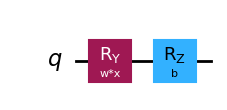

In [3]:
x_p = Parameter('x')
w_p = Parameter('w')
b_p = Parameter('b')

qc = QuantumCircuit(1)
qc.ry(x_p * w_p, 0)
qc.rz(b_p, 0)

input_params = [x_p]
trainable_params = [w_p, b_p]
qc.draw('mpl')


# <b>QNN & Observable Definition </b> <a id="qnn"></a>
After defining the parametric quantum circuit, we wrap it inside an `EstimatorQNN`. This object connects the quantum circuit to the machine learning workflow.

The QNN produces its output by measuring an **observable**. In this notebook, we use the Pauli-Z observable:

$$
Z =
\begin{pmatrix}
1 & 0 \\
0 & -1
\end{pmatrix}
$$

Measuring the expectation value of Pauli-Z gives a classical number in the range:

$$
[-1, 1]
$$

This number tells us, roughly speaking, whether the final qubit state is closer to $|0\rangle$ or $|1\rangle$. Since the result is a single scalar value, it can be used directly as the prediction of the QNN for this regression task.

In [4]:
observable = SparsePauliOp.from_list([("Z", 1)])

qnn = EstimatorQNN(
    circuit=qc,
    observables=observable,
    input_params=input_params,
    weight_params=trainable_params
)

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


# <b>Training with Regularization </b> <a id="train"></a>
During training, the QNN updates its trainable parameters so that its predictions become closer to the target values in the training set.

Since the dataset contains noise, we do not want the model to fit every small fluctuation perfectly. This problem is called **overfitting**: the model performs very well on the training data but poorly on unseen test data.

Regularization is any technique that helps control this behavior. In this notebook, we use a simple form of regularization by limiting the number of optimizer iterations:

```python
maxiter = 50

In [5]:
regressor = NeuralNetworkRegressor(
    neural_network=qnn,
    loss="squared_error",
    optimizer=L_BFGS_B(maxiter=50), # Regularization via early stopping/iteration limit
    initial_point=np.random.uniform(-0.1, 0.1, qnn.num_weights)
)

print("Training Regressor...")
regressor.fit(X_train_scaled, y_train_scaled)

Training Regressor...


# <b>Results and Evaluation </b> <a id="res"></a>
After training, we use the QNN to predict the target values for the test set. These are input points that the model did not see during training, so they give us a better idea of how well the model has learned the underlying pattern rather than just memorizing the training data. 

We then plot:
- the training data,
- the test data,
- and the QNN predictions.

This visual comparison helps us evaluate whether the QNN captures the general shape of the noisy quadratic function. If the predicted curve follows the test data reasonably well, it suggests that the model is able to generalize to unseen inputs.

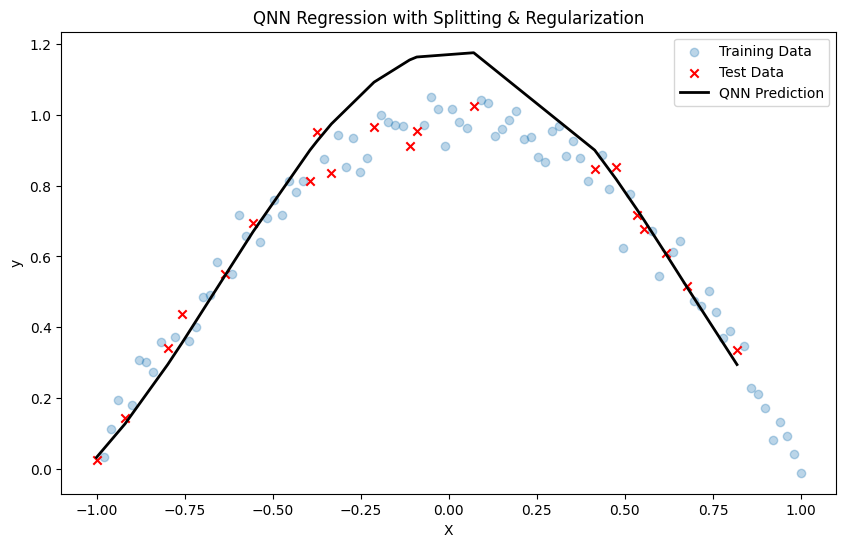

In [6]:
y_pred_scaled = regressor.predict(X_test_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, label='Training Data', alpha=0.3)
plt.scatter(X_test, y_test, color='red', label='Test Data', marker='x')

# Plot prediction curve
sort_idx = np.argsort(X_test.flatten())
plt.plot(X_test[sort_idx], y_pred[sort_idx], color='black', lw=2, label='QNN Prediction')

plt.title("QNN Regression with Splitting & Regularization")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# <b>Moving forward </b> <a id="move"></a>
The single-qubit QNN in this notebook is intentionally simple. It is useful for understanding the basic structure of a quantum neural network:

1. encode classical data into a quantum circuit,
2. apply trainable quantum gates,
3. measure an observable,
4. use a classical optimizer to update the parameters.

However, our hackathon challenge goes beyond this toy example. You will design QNNs for a real regression task: predicting the superconducting critical temperature $T_c$ of materials from physical and material descriptors. This will likely require more input features, more qubits, deeper circuits, and possibly entanglement between qubits.

When moving from simulation to real quantum hardware, circuit design becomes just as important as model accuracy. The IBM quantum processor at your disposal for this challenge, `ibm_basquecountry`, has a fixed qubit connectivity, based on the **heavy-hex lattice**. This means that not every qubit can directly interact with every other qubit. If a QNN circuit uses two-qubit gates between qubits that are not physically connected, the transpiler must insert additional routing operations, such as SWAP gates. These extra gates increase circuit depth and make the model more vulnerable to noise.

For this reason, a good QNN for hardware is not necessarily the largest or most expressive one. A practical QNN should balance:

- **expressivity**, so the model can learn useful patterns from the data;
- **trainability**, so the optimizer can find good parameters;
- **hardware efficiency**, so the circuit can run on real devices with limited noise;
- **robustness**, so the model still performs reasonably under finite shots, gate errors, and readout errors.

In this hackathon, you are encouraged to think beyond ideal simulation and explore hardware-aware strategies such as:

- using **hardware-efficient ansätze** with low-depth layers and hardware-friendly gates;
- designing entanglement patterns that respect the device connectivity;
- applying **hardware-aware transpilation** to reduce circuit depth and two-qubit gate overhead;
- comparing ideal simulation, noisy simulation, and real-device execution;
- using error-mitigation or noise-management techniques such as measurement-error mitigation, zero-noise extrapolation, dynamical decoupling, or shot-noise analysis.


# <b>Useful resources </b> <a id="use"></a>

The following resources may be useful when extending this introductory QNN example toward the full challenge.

### <b>Qiskit and Qiskit Machine Learning </b>

- [Qiskit documentation](https://quantum.cloud.ibm.com/docs/guides/tools-intro)  
  General entry point for Qiskit, IBM Quantum, circuits, primitives, transpilation, and runtime execution.

- [Qiskit Machine Learning documentation](https://qiskit-community.github.io/qiskit-machine-learning/)  
  Documentation for quantum machine learning tools, including quantum kernels, QNNs, classifiers, and regressors.

- [Qiskit Machine Learning tutorials](https://qiskit-community.github.io/qiskit-machine-learning/tutorials/index.html)  
  Collection of tutorials covering QNNs, neural network classifiers and regressors, quantum kernels, hybrid QNNs, and model training workflows.

- [EstimatorQNN documentation](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.neural_networks.EstimatorQNN.html)  
  Reference page for the `EstimatorQNN` class used to build QNNs based on expectation values.

- [NeuralNetworkRegressor documentation](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.NeuralNetworkRegressor.html)  
  Reference page for the Qiskit Machine Learning regressor interface used in this notebook.

### <b>Optimizers and variational algorithms </b>

- [Qiskit Algorithms documentation](https://qiskit-community.github.io/qiskit-algorithms/apidocs/qiskit_algorithms.html)  
  Documentation for variational algorithms and related tools.

- [Qiskit Algorithms optimizers](https://qiskit-community.github.io/qiskit-algorithms/apidocs/qiskit_algorithms.optimizers.html)  
  Reference page for classical optimizers such as `COBYLA`, `L_BFGS_B`, `SPSA`, `GradientDescent`, and others.

- [Variational quantum algorithms course](https://quantum.cloud.ibm.com/learning/en/courses/utility-scale-quantum-computing/variational-quantum-algorithms)  
  IBM Quantum learning material on variational quantum algorithms, which are the broader family of hybrid algorithms that includes many QNN workflows.

### <b>Hardware-aware circuit design and transpilation </b>

- [IBM Quantum heavy-hex lattice blog](https://www.ibm.com/quantum/blog/heavy-hex-lattice)  
  Introduction to the heavy-hex connectivity used in `ibm_basquecountry`.

- [Transpile with pass managers](https://quantum.cloud.ibm.com/docs/guides/transpile-with-pass-managers)  
  Guide explaining how to use pass managers to transpile circuits for specific quantum backends.

- [`generate_preset_pass_manager` documentation](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.transpiler.generate_preset_pass_manager)  
  API reference for generating preset transpilation pass managers, useful for hardware-aware circuit optimization.

- [Qiskit transpiler preset pass managers](https://quantum.cloud.ibm.com/docs/api/qiskit/transpiler_preset)  
  Reference page for preset transpilation workflows and optimization levels.

### <b>Error mitigation and noise-aware execution </b>

- [Error mitigation and suppression techniques](https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques)  
  Overview of error suppression and error mitigation methods available through Qiskit Runtime.

- [Configure error mitigation](https://quantum.cloud.ibm.com/docs/guides/configure-error-mitigation)  
  Practical guide for configuring resilience and mitigation options when running workloads on IBM Quantum systems.

- [Combine error mitigation options with the Estimator primitive](https://quantum.cloud.ibm.com/docs/tutorials/combine-error-mitigation-techniques)  
  Tutorial showing how to use techniques such as dynamical decoupling, measurement error mitigation, gate twirling, and zero-noise extrapolation.

- [Resilience options for Qiskit Runtime Estimator](https://quantum.cloud.ibm.com/docs/api/qiskit-ibm-runtime/options-resilience-options-v2)  
  API reference for configuring runtime resilience options such as measurement mitigation, zero-noise extrapolation, and probabilistic error cancellation.

### <b>Dataset for the challenge </b>

- [Superconductivity dataset - UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/464/superconductivty+data)  
  Dataset proposed for the hackathon challenge, containing material descriptors and superconducting critical temperature values.